In [ ]:
import marimo as mo

#Строим baseline модель бинарной классификации

In [ ]:
from copy import deepcopy
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import pickle
import os

In [ ]:
#разделяем датасет на метку и признаки
data=pd.read_csv('data\processed\clean_data.csv', delimiter=',')
data = data.dropna(subset=['text']) #мы сохранили чистый датасет на прошлом этапе, но при read csv появляются пустые ячейки (надо фиксить, но пока просто удаляем, потому что количество пустых строк в столбце text менее 1 процента)
X=data.drop(columns=['y'])
y=data['y']

In [ ]:
X_train, X_test, y_train_logreg, y_test_logreg = train_test_split(
    X,y,
    test_size=0.2,
    random_state=17,
    stratify=y
)
#применяем tfidf[TF (Term Frequency) — как часто слово встречается в документе
#IDF (Inverse Document Frequency) — насколько слово редкое во всех документах]
#к обучающей выборке, чтобы не было утечки данных
text_trans=TfidfVectorizer(
    ngram_range=(1,3), #учитывает слова отдельные слова, пары и словосочетания до 3 слов
    max_features=20000, #кол-во частотных признаков
    min_df=5, #игнорирует слова, которые встречаются менее чем в 5 твитах
    stop_words='english' #убираем местоимения
)

cat_trans=OneHotEncoder(handle_unknown='ignore')
preprocessor=ColumnTransformer(
    transformers=[
        ('text',text_trans,'text'),
        ('cat', cat_trans, ['day','time'])
    ]
)

baseline - логистическая регрессия (хорошо интерпретируема, хороша работает с текст данными и отправная точка в работе с NLP задачами)

In [ ]:
model=Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000, #количество итераций
        random_state=17
    ))
])
model.fit(X_train,y_train_logreg)

<iframe srcdoc='<style>#sk-container-id-1 {/* Definition of color scheme common for light and dark mode */--sklearn-color-text: #000;--sklearn-color-text-muted: #666;--sklearn-color-line: gray;/* Definition of color scheme for unfitted estimators */--sklearn-color-unfitted-level-0: #fff5e6;--sklearn-color-unfitted-level-1: #f6e4d2;--sklearn-color-unfitted-level-2: #ffe0b3;--sklearn-color-unfitted-level-3: chocolate;/* Definition of color scheme for fitted estimators */--sklearn-color-fitted-level-0: #f0f8ff;--sklearn-color-fitted-level-1: #d4ebff;--sklearn-color-fitted-level-2: #b3dbfd;--sklearn-color-fitted-level-3: cornflowerblue;/* Specific color for light theme */--sklearn-color-text-on-default-background: var(--sg-text-color, var(--theme-code-foreground, var(--jp-content-font-color1, black)));--sklearn-color-background: var(--sg-background-color, var(--theme-background, var(--jp-layout-color0, white)));--sklearn-color-border-box: var(--sg-text-color, var(--theme-code-foreground, var(--jp-content-font-color1, black)));--sklearn-color-icon: #696969;@media (prefers-color-scheme: dark) {/* Redefinition of color scheme for dark theme */--sklearn-color-text-on-default-background: var(--sg-text-color, var(--theme-code-foreground, var(--jp-content-font-color1, white)));--sklearn-color-background: var(--sg-background-color, var(--theme-background, var(--jp-layout-color0, #111)));--sklearn-color-border-box: var(--sg-text-color, var(--theme-code-foreground, var(--jp-content-font-color1, white)));--sklearn-color-icon: #878787;}}#sk-container-id-1 {color: var(--sklearn-color-text);}#sk-container-id-1 pre {padding: 0;}#sk-container-id-1 input.sk-hidden--visually {border: 0;clip: rect(1px 1px 1px 1px);clip: rect(1px, 1px, 1px, 1px);height: 1px;margin: -1px;overflow: hidden;padding: 0;position: absolute;width: 1px;}#sk-container-id-1 div.sk-dashed-wrapped {border: 1px dashed var(--sklearn-color-line);margin: 0 0.4em 0.5em 0.4em;box-sizing: border-box;padding-bottom: 0.4em;background-color: var(--sklearn-color-background);}#sk-container-id-1 div.sk-container {/* jupyter's `normalize.less` sets `[hidden] { display: none; }`but bootstrap.min.css set `[hidden] { display: none !important; }`so we also need the `!important` here to be able to override thedefault hidden behavior on the sphinx rendered scikit-learn.org.See: https://github.com/scikit-learn/scikit-learn/issues/21755 */display: inline-block !important;position: relative;}#sk-container-id-1 div.sk-text-repr-fallback {display: none;}div.sk-parallel-item,div.sk-serial,div.sk-item {/* draw centered vertical line to link estimators */background-image: linear-gradient(var(--sklearn-color-text-on-default-background), var(--sklearn-color-text-on-default-background));background-size: 2px 100%;background-repeat: no-repeat;background-position: center center;}/* Parallel-specific style estimator block */#sk-container-id-1 div.sk-parallel-item::after {content: "";width: 100%;border-bottom: 2px solid var(--sklearn-color-text-on-default-background);flex-grow: 1;}#sk-container-id-1 div.sk-parallel {display: flex;align-items: stretch;justify-content: center;background-color: var(--sklearn-color-background);position: relative;}#sk-container-id-1 div.sk-parallel-item {display: flex;flex-direction: column;}#sk-container-id-1 div.sk-parallel-item:first-child::after {align-self: flex-end;width: 50%;}#sk-container-id-1 div.sk-parallel-item:last-child::after {align-self: flex-start;width: 50%;}#sk-container-id-1 div.sk-parallel-item:only-child::after {width: 0;}/* Serial-specific style estimator block */#sk-container-id-1 div.sk-serial {display: flex;flex-direction: column;align-items: center;background-color: var(--sklearn-color-background);padding-right: 1em;padding-left: 1em;}/* Toggleable style: style used for estimator/Pipeline/ColumnTransformer box that isclickable and can be expanded/collapsed.- Pipeline and ColumnTransformer use this feature and define the default style- Estimators will overwrite 

In [ ]:
y_train_prediction_logreg=model.predict(X_train)
y_train_prediction_proba_logreg=model.predict_proba(X_train)[:, 1]
y_test_prediction_logreg=model.predict(X_test)
y_test_prediction_proba_logreg=model.predict_proba(X_test)[:, 1]
df=pd.DataFrame(
    {"Какая выборка?": ["Train","Test"],
     "Accuracy метрика": [accuracy_score(y_train_logreg, y_train_prediction_logreg),accuracy_score(y_test_logreg,y_test_prediction_logreg)],
     "F1-мера": [f1_score(y_train_logreg, y_train_prediction_logreg),f1_score(y_test_logreg,y_test_prediction_logreg)]
        }
)
print(df)

  Какая выборка?  Accuracy метрика   F1-мера
0          Train          0.795597  0.799780
1           Test          0.788302  0.792749


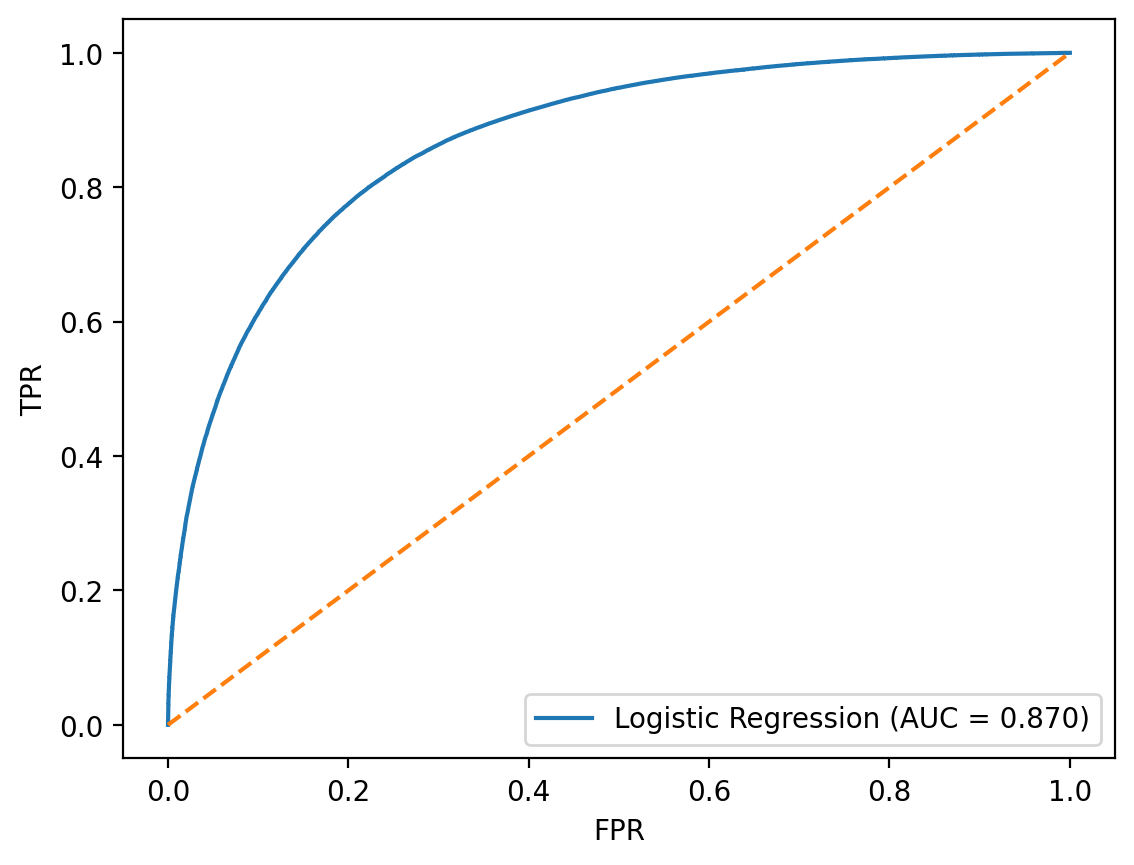

In [ ]:
#ROC-AUC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test_logreg, y_test_prediction_proba_logreg) #false positive rate (доля ложноположительных срабатываний), true positive rate (чувствительность recall)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg) #AUC = 1 — идеальная классификация, 0.5 — случайная

plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_logreg:.3f})')

plt.plot([0,1],[0,1],'--') ## Эта линия соответствует случайной модели (AUC=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.savefig('image/logreg_roc_curve.png')
plt.show()

In [ ]:
cm = confusion_matrix(y_test_logreg, y_test_prediction_logreg) #матрица неточностей, показывающая TP, FN, TN, FP
cm_df = pd.DataFrame(
    cm,
    index=['Negative', 'Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

print(cm_df)
print(f"Precission for train: {precision_score(y_train_logreg, y_train_prediction_logreg):.3f}\nRecall for train: {recall_score(y_train_logreg, y_train_prediction_logreg):.3f}\nPrecission for test: {precision_score(y_test_logreg, y_test_prediction_logreg):.3f}\nRecall for test: {recall_score(y_test_logreg, y_test_prediction_logreg):.3f}")

          Predicted Negative  Predicted Positive
Negative              122422               37247
Positive               30346              129274
Precission for train: 0.784
Recall for train: 0.817
Precission for test: 0.776
Recall for test: 0.810


In [ ]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coef = model.named_steps['classifier'].coef_[0]

top_pos = coef.argsort()[-5:]
top_neg = coef.argsort()[:5]

print("=== POSITIVE WORDS ===")
for i in top_pos:
    clean_name = re.sub(r'^text__', '', feature_names[i])
    print(f"{clean_name}: {coef[i]:.1f}")

print("\n=== NEGATIVE WORDS ===")
for i in top_neg:
    clean_name = re.sub(r'^text__', '', feature_names[i])
    print(f"{clean_name}: {coef[i]:.1f}")

=== POSITIVE WORDS ===
thank: 4.5
dont sad: 4.5
thanks: 4.7
isnt bad: 5.0
wish luck: 5.7

=== NEGATIVE WORDS ===
sad: -11.2
poor: -6.6
bummed: -6.6
miss: -6.5
sadly: -6.4


#Итог
Собрана рабочая базовая модель логистической регрессии.

##Результаты
|Метрика|Train|Test|
|:-----:|:----:|:--:|
|Accuracy|0.795597|0.788302|
|F1-мера|0.799780|0.792749|
|Recall|0.817|0.810|
|Precission|0.784|0.776|

##Матрица неточностей
||Прогноз y>0|Прогноз y<0|
|:-----:|:----:|:--:|
|Реал y>0|129274|30346|
|Реал y<0|37247|122422|

, где TP = 129274, TN = 122422, FP = 37247, FN = 30346

Слова имеющие наибольший вес в модели:

|Позитивные слова: вес|Негативные слова: вес|
|:-----:|:----:|
|thank: 4.5|sad: -11.2|
|dont sad: 4.5|poor: -6.6|
|thanks: 4.7|bummed: -6.6|
|isnt bad: 5.0|miss: -6.5|
|wish luck: 5.7|sadly: -6.4|

##Следующий шаг - улучшение модели с использованием методов бустинга

In [ ]:
os.makedirs('models', exist_ok=True)
package = {
    # Модели
    'model': model,    
    # Признаки
    'cat_features': ['day', 'time'],
    'text_features': ['text'],
    'text_truncate': 150,
}

# Сохраняем одним файлом
with open('models/logreg.pkl', 'wb') as f:
    pickle.dump(package, f)